In [1]:
import pandas as pd
import plotly.express as px

tabela_df = pd.read_csv('[Opcional] Projeto Exercício de Revisão - Vendas_Chocolate.csv',sep=';')

display(tabela_df)

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas,Data de Hoje
0,João Rocha,Reino Unido,Chocolate com Menta e Flocos,04/01/2022,"$5,320.00",180.0,03/02/2026
1,Vanderlei Teixeira,Índia,NaN,01/08/2022,"$7,896.00",94.0,NaN
2,Gisele Barbosa,Índia,Cubos de Manteiga de Amendoim,07/07/2022,"$4,501.00",91.0,NaN
3,Janaína Moreira,Austrália,Cubos de Manteiga de Amendoim,27/04/2022,"$12,726.00",342.0,NaN
4,João Rocha,Reino Unido,Cubos de Manteiga de Amendoim,24/02/2022,"$13,685.00",184.0,NaN
...,...,...,...,...,...,...,...
3277,Karina Machado,Austrália,Especiais Apimentados Finos,17/05/2024,"$5,303.58",354.0,NaN
3278,João Rocha,EUA,Chocolate Branco,07/06/2024,"$7,339.32",121.0,NaN
3279,Célio Bonfim,Canadá,Xarope de Chocolate Orgânico,26/07/2024,$616.09,238.0,NaN
3280,Doroti Santos,Índia,Bombas de Chocolate,28/07/2024,"$2,504.62",397.0,NaN


In [2]:
# 1. Inspeção de Vendas
# 2. Tratamento de Dados
# 3. Análises

In [3]:
# 1. Inspeção de Vendas
# 1.1 15 primeiras linhas
#display(tabela_df.head(15))
# 1.2 15 ultimas linhas
#display(tabela_df.tail(15))
# 1.3 15 linhas aleatórias
#display(tabela_df.sample(15))
# 1.4 tamanho da table
#display(tabela_df.shape)
# 1.5 inforamçoes da tabela
display(tabela_df.info()) # mudar o formto de dado da data, valor e caixas enviadas
# 1.6 medidas estatisticas da tabela
display(tabela_df.describe())
# 1.7 nome das colunas
display(list(tabela_df.columns))

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Vendedor         3250 non-null   str    
 1   País             3250 non-null   str    
 2   Produto          3250 non-null   str    
 3   Data             3282 non-null   str    
 4   Valor            3282 non-null   str    
 5   Caixas Enviadas  3250 non-null   float64
 6   Data de Hoje     1 non-null      str    
dtypes: float64(1), str(6)
memory usage: 386.2 KB


None

,Caixas Enviadas
count,3250.000000
mean,164.220923
std,123.740233
min,1.000000
25%,71.000000
50%,136.500000
75%,232.000000
max,778.000000


['Vendedor',
 'País',
 'Produto',
 'Data',
 'Valor',
 'Caixas Enviadas',
 'Data de Hoje']

In [4]:
# 2. Tratamento de Dados
# 2.1 Excluir coluna Data Hoje
tratamento_tabela_df = tabela_df.drop(columns=['Data de Hoje'])
# 2.2 Ajustar valores nulos em Caixas Enviadas
#tratamento_tabela_df['Caixas Enviadas'] = tratamento_tabela_df['Caixas Enviadas'].fillna('0')
# 2.3 Ajustar valores nulos nas ourtas colunas
tratamento_tabela_df = tratamento_tabela_df.dropna() 
# 2.4 Mudar tipo de dados da Data 
tratamento_tabela_df['Data'] = pd.to_datetime(tratamento_tabela_df['Data'],dayfirst=True)
# 2.5 Mudar tipo de dados do Valor
tratamento_tabela_df['Valor'] = tratamento_tabela_df['Valor'].str.replace('$','',regex=False)
tratamento_tabela_df['Valor'] = tratamento_tabela_df['Valor'].str.replace(',','',regex=False)
tratamento_tabela_df['Valor'] = tratamento_tabela_df['Valor'].astype(float)
# 2.6 Mudar tipo de dados de Caixa Enviada
tratamento_tabela_df['Caixas Enviadas'] = tratamento_tabela_df['Caixas Enviadas'].astype(int)
# 2.7 Ajustar Formatação dos valores nas Colunas País, Vendedor e Produto
tratamento_tabela_df['País'] = tratamento_tabela_df['País'].str.title()
tratamento_tabela_df['Vendedor'] = tratamento_tabela_df['Vendedor'].str.title()
tratamento_tabela_df['Produto'] = tratamento_tabela_df['Produto'].str.title()
# 2.8 Ordenando de acordo com a Data
tratamento_tabela_df = tratamento_tabela_df.sort_values(by='Data')
# 2.8 Resetando os indices
tratamento_tabela_df = tratamento_tabela_df.reset_index(drop=True)


display(tratamento_tabela_df.info())
display(tratamento_tabela_df)

<class 'pandas.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Vendedor         3155 non-null   str           
 1   País             3155 non-null   str           
 2   Produto          3155 non-null   str           
 3   Data             3155 non-null   datetime64[us]
 4   Valor            3155 non-null   float64       
 5   Caixas Enviadas  3155 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 289.1 KB


None

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas
0,Célio Bonfim,Reino Unido,Chocolate Branco,2022-01-03,3269.00,226
1,Marina Oliveira,Canadá,Especiais Apimentados Finos,2022-01-03,3528.00,336
2,Doroti Santos,Reino Unido,99% Amargo E Puro,2022-01-03,9310.00,282
3,Andréia Campos,Canadá,Barras Recheadas Com Caramelo,2022-01-03,7154.00,348
4,Camila Castro,Reino Unido,Chocolate Branco,2022-01-03,9982.00,187
...,...,...,...,...,...,...
3150,Hugo Aguiar,Austrália,99% Amargo E Puro,2024-08-26,3277.47,131
3151,Hugo Aguiar,Reino Unido,Bombas De Chocolate,2024-08-30,1955.20,250
3152,Beatriz Motta,Nova Zelândia,Barras 85% Cacau,2024-08-30,12886.26,21
3153,João Rocha,Índia,Chocolate Com Amêndoas,2024-08-30,11793.40,101


,Mes/Ano,Valor
0,2022-01,860363.00
1,2022-02,699377.00
2,2022-03,726418.00
3,2022-04,653198.00
4,2022-05,740103.00
5,2022-06,836465.00
6,2022-07,772177.00
7,2022-08,709065.00
8,2023-01,900155.00
9,2023-02,729416.95


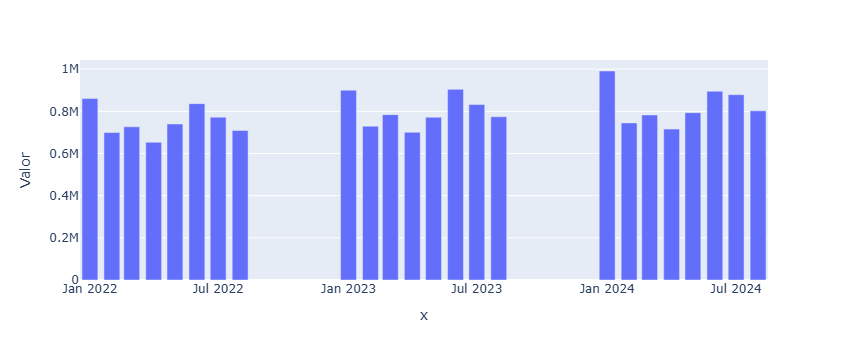

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas,Ano,Mes/Ano
0,Célio Bonfim,Reino Unido,Chocolate Branco,2022-01-03,3269.00,226,2022,2022-01
1,Marina Oliveira,Canadá,Especiais Apimentados Finos,2022-01-03,3528.00,336,2022,2022-01
2,Doroti Santos,Reino Unido,99% Amargo E Puro,2022-01-03,9310.00,282,2022,2022-01
3,Andréia Campos,Canadá,Barras Recheadas Com Caramelo,2022-01-03,7154.00,348,2022,2022-01
4,Camila Castro,Reino Unido,Chocolate Branco,2022-01-03,9982.00,187,2022,2022-01
...,...,...,...,...,...,...,...,...
3150,Hugo Aguiar,Austrália,99% Amargo E Puro,2024-08-26,3277.47,131,2024,2024-08
3151,Hugo Aguiar,Reino Unido,Bombas De Chocolate,2024-08-30,1955.20,250,2024,2024-08
3152,Beatriz Motta,Nova Zelândia,Barras 85% Cacau,2024-08-30,12886.26,21,2024,2024-08
3153,João Rocha,Índia,Chocolate Com Amêndoas,2024-08-30,11793.40,101,2024,2024-08


In [5]:
# 3. Análises - feature engineering
analise_tabela_df = tratamento_tabela_df
analise_tabela_df['Ano'] = analise_tabela_df['Data'].dt.year
analise_tabela_df['Mes/Ano'] = analise_tabela_df['Data'].dt.to_period('M')
# 3.1 Analise de Crescimento de Vendas
vendas_mes = analise_tabela_df[['Mes/Ano','Valor']]
vendas_mes = vendas_mes.groupby('Mes/Ano',as_index=False).sum()
display(vendas_mes)
# 3.1.1 Grafico
grafico_vendas_mes = px.bar(vendas_mes,x=vendas_mes['Mes/Ano'].astype(str),y='Valor')
grafico_vendas_mes.show()

display(analise_tabela_df)

In [6]:
# 3. Análises 
# 3.2 Analise de Volume e Ticket medio
vendas_ano = analise_tabela_df[['Ano','Valor','Caixas Enviadas']]
vendas_ano = vendas_ano.groupby(by='Ano', as_index=False).sum()
vendas_ano['Ticket Médio'] = vendas_ano['Valor']/vendas_ano['Caixas Enviadas']
vendas_ano['%Crescimento'] = vendas_ano['Valor'].pct_change()
vendas_ano_formatacao = vendas_ano.style.format({
    'Valor':'${:,.2f}',
    'Caixas Enviadas':'{:,.0f}',
    'Ticket Médio': '${:,.2f}',
    '%Crescimento': '{:,.1%}'
})
display(vendas_ano_formatacao)

,Ano,Valor,Caixas Enviadas,Ticket Médio,%Crescimento
0,2022,"$5,997,166.00","171,422",$34.98,nan%
1,2023,"$6,396,868.89","173,970",$36.77,6.7%
2,2024,"$6,604,719.00","172,361",$38.32,3.2%


,Ano,Produto,Valor
0,2022,99% Amargo E Puro,270144.00
1,2022,Amêndoas Cobertas Com Chocolate,238847.00
2,2022,Barras 85% Cacau,283297.00
3,2022,Barras De Chocolate Ao Leite,258867.00
4,2022,Barras De Frutas E Castanhas,236922.00
...,...,...,...
61,2024,Gotas De Chocolate De Confeiteiro,281787.05
62,2024,Mordidas 50% Cacau,355627.08
63,2024,Mordidas 70% Cacau,237490.12
64,2024,Salgadinho Suave E Sedoso,370077.04


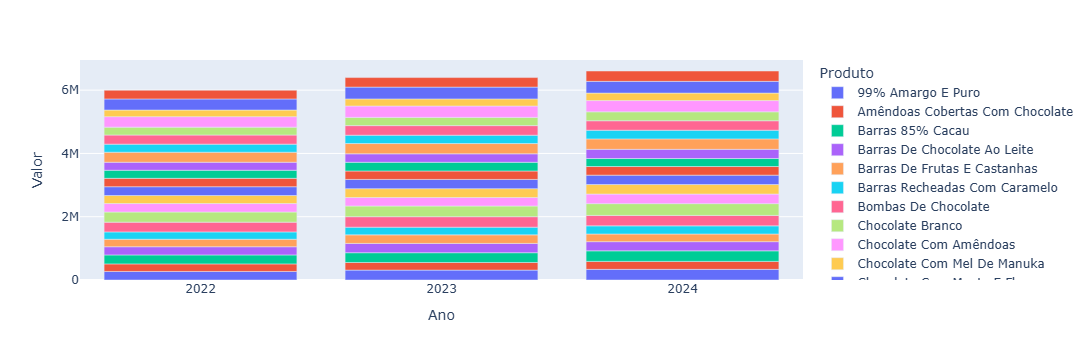

In [10]:
# 3. Análises 
# 3.3 Analise por produto (anual)
produtos_ano = analise_tabela_df[['Ano','Produto','Valor']]
produtos_ano = produtos_ano.groupby(by=['Ano','Produto'],as_index=False).sum()
display(produtos_ano)
# 3.4 Grafico
grafico_produtos_ano = px.bar(produtos_ano,x='Ano',y='Valor',color='Produto')
grafico_produtos_ano.show()